In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score, roc_curve
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [3]:
# Column names taken from cmc.names (UCI)
cmc_cols = [
    "wife_age",
    "wife_education",
    "husband_education",
    "num_children",
    "wife_religion",
    "wife_working",
    "husband_occupation",
    "standard_of_living",
    "media_exposure",
    "contraceptive_method"  
]

cmc = pd.read_csv("cmc.data", names=cmc_cols)
cmc.head()
cmc.shape
print(cmc)

      wife_age  wife_education  husband_education  num_children  \
0           24               2                  3             3   
1           45               1                  3            10   
2           43               2                  3             7   
3           42               3                  2             9   
4           36               3                  3             8   
...        ...             ...                ...           ...   
1468        33               4                  4             2   
1469        33               4                  4             3   
1470        39               3                  3             8   
1471        33               3                  3             4   
1472        17               3                  3             1   

      wife_religion  wife_working  husband_occupation  standard_of_living  \
0                 1             1                   2                   3   
1                 1             1        

In [4]:
# Selecting Q1 variables
cmc_q1 = cmc[['wife_education', 'media_exposure', 'contraceptive_method']].copy()

# Recoding variables
cmc_q1['contraceptive_use'] = np.where(cmc_q1['contraceptive_method'] == 1, 0, 1) # 1 = 0 (no use) 2 or 3 = 1 (any use)
cmc_q1['media_exposure_rev'] = np.where(cmc_q1['media_exposure'] == 0, 1, 0) # more intuitive -> 1 = Good exposure, 0 = Poor exposure

# Checking missingness
cmc_q1.isna().sum()

wife_education          0
media_exposure          0
contraceptive_method    0
contraceptive_use       0
media_exposure_rev      0
dtype: int64

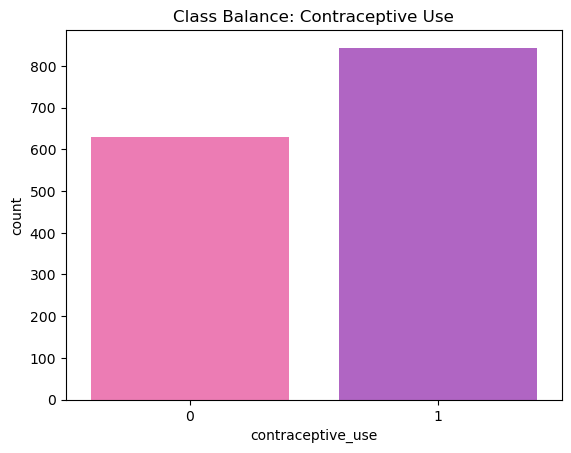

In [5]:
cmc_q1['contraceptive_use'].value_counts(normalize=True) # proportions of classes
sns.countplot(data=cmc_q1,x='contraceptive_use',hue='contraceptive_use',palette={0: "hotpink", 1: "mediumorchid"},legend=False)
plt.title("Class Balance: Contraceptive Use");

,Variable,VIF
0,wife_education,8.578014
1,media_exposure_rev,8.578014


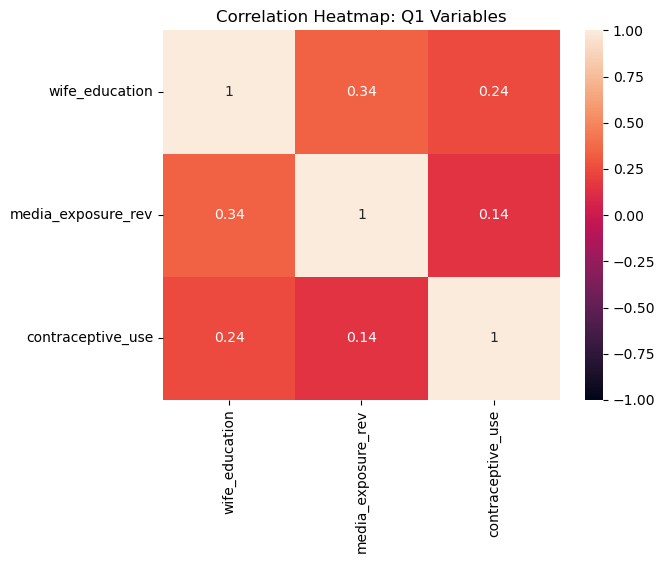

In [26]:
# Multicollinearity
corr = cmc_q1[['wife_education', 'media_exposure_rev', 'contraceptive_use']].corr()
sns.heatmap(corr, annot=True, cmap="rocket", vmin=-1, vmax=1)
plt.title("Correlation Heatmap: Q1 Variables");

# VIF
X_vif_q1 = cmc_q1[["wife_education", "media_exposure_rev"]]
vif_df_q1 = pd.DataFrame({"Variable": X_vif_q1.columns,
                          "VIF": [variance_inflation_factor(X_vif_q1.values, i)
                                  for i in range(X_vif_q1.shape[1])]})

vif_df_q1

In [17]:
from sklearn.model_selection import train_test_split

# Assigning features and target
X = cmc_q1[['wife_education', 'media_exposure_rev']]
X = sm.add_constant(X)
Y = cmc_q1['contraceptive_use']

# Train–test split (80/20) (stratifying by outcome class)
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=23, stratify=Y)

# Fit model on training data
logit_train = sm.Logit(y_train, X_train).fit()
print(logit_train.summary())

Optimization terminated successfully.
         Current function value: 0.645658
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:      contraceptive_use   No. Observations:                 1178
Model:                          Logit   Df Residuals:                     1175
Method:                           MLE   Df Model:                            2
Date:                Fri, 19 Dec 2025   Pseudo R-squ.:                 0.05391
Time:                        01:59:54   Log-Likelihood:                -760.58
converged:                       True   LL-Null:                       -803.93
Covariance Type:            nonrobust   LLR p-value:                 1.504e-19
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -1.6466      0.261     -6.309      0.000      -2.158      -1.135
wife_

In [18]:
# OR table
params = logit_train.params
conf = logit_train.conf_int()
odds_df = pd.DataFrame({"OR": np.exp(params),"2.5%": np.exp(conf[0]),"97.5%": np.exp(conf[1])}) 
print(odds_df)

                          OR      2.5%     97.5%
const               0.192711  0.115549  0.321403
wife_education      1.639124  1.443541  1.861207
media_exposure_rev  1.710065  1.040126  2.811506


Optimization terminated successfully.
         Current function value: 0.664083
         Iterations 5
0.5993002723771954


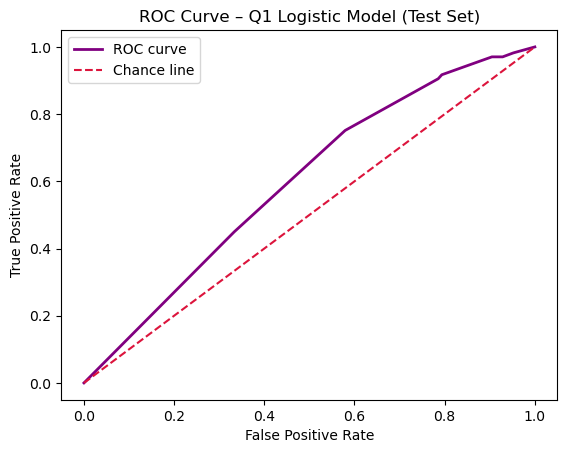

In [19]:
# MODEL on TEST set
logit_test = sm.Logit(y_test, X_test).fit()

# Model Peformance on Test set
y_pred_probs = logit_test.predict(X_test)
auc_q1 = roc_auc_score(y_test, y_pred_probs)
print(auc_q1)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)
plt.plot(fpr, tpr, color="purple", linewidth=2, label="ROC curve")
plt.plot([0,1], [0,1], '--', color="crimson", label="Chance line")
plt.title("ROC Curve – Q1 Logistic Model (Test Set)")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend();

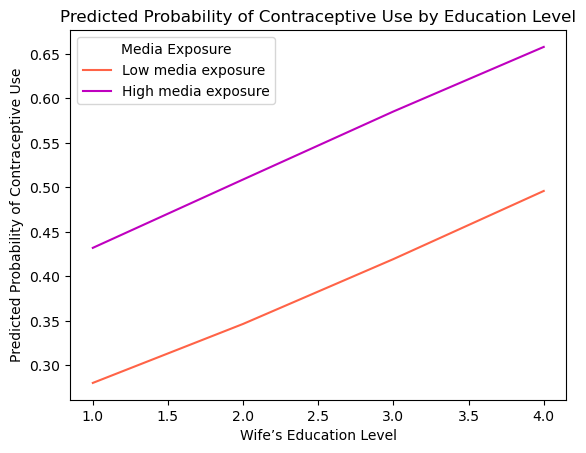

In [25]:
# Predicing  probability of contraceptive use by education level, stratified by media exposure
# Unique education levels
edu_levels = sorted(cmc_q1["wife_education"].unique())

# Create prediction grid
pred_df = pd.DataFrame({"wife_education": edu_levels * 2, # 2 sets for mediaa levels
                        "media_exposure_rev": [0]*len(edu_levels) + [1]*len(edu_levels)}) # seperating media exposure - 0 and 1

# Add intercept
pred_df["const"] = 1

# Align column order with model
pred_df = pred_df[X_test.columns]

# Predicted probabilities
pred_df["pred_prob"] = logit_test.predict(pred_df)

# Label media exposure for plotting
pred_df["Media exposure"] = pred_df["media_exposure_rev"].map({0: "Low media exposure", 1: "High media exposure"})

# Plot
sns.lineplot(data=pred_df,x="wife_education",y="pred_prob",hue="Media exposure",palette=["tomato", "m"])

plt.title("Predicted Probability of Contraceptive Use by Education Level")
plt.xlabel("Wife’s Education Level")
plt.ylabel("Predicted Probability of Contraceptive Use")
plt.legend(title="Media Exposure")
plt.show()